In [70]:
import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# transform img into desired form - grayscale and tensor
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor() # normalizes pixel (0,1); shape: (c,h,w); dtype - float
])

# loading img
image_path = 'bcsiitk.png'
try:
    image = Image.open(image_path)
    img_tensor = transform(image).unsqueeze(0) # to add the batch dim (normally we dont do this because the dataloader takes care of this)
except FileNotFoundError:
    print("no img found")


In [71]:
# DEFINING KERNELS

# SOBEL
# horizontal edge kernel (sobel x)
sobel_x_kernel = torch.tensor([
    [-1.0, 0.0, 1.0],
    [-2.0, 0.0, 2.0],
    [-1.0, 0.0, 1.0]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0) # since conv2d expects input of shape (in_channels, out_channels, h, w) here (1,1,3,3)

# vertical edge kernel (sobel y)
sobel_y_kernel = torch.tensor([
    [-1.0, -2.0, -1.0],
    [ 0.0,  0.0,  0.0],
    [ 1.0,  2.0,  1.0]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)


# SCHARR
# horizontal edge kernel (scharr x)
scharr_x_kernel = torch.tensor([
    [-3.0, 0.0, 3.0],
    [-10.0, 0.0, 10.0],
    [-3.0, 0.0, 3.0]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0) # since conv2d expects input of shape (in_channels, out_channels, h, w) here (1,1,3,3)

# vertical edge kernel (scharr y)
scharr_y_kernel = torch.tensor([
    [-3.0, -10.0, -3.0],
    [ 0.0,  0.0,  0.0],
    [ 3.0,  10.0,  3.0]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)


#LAPLACIAN
laplacian_kernel = torch.tensor([
    [ 0.0,  1.0,  0.0],
    [ 1.0, -4.0,  1.0],
    [ 0.0,  1.0,  0.0]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)


# LAPLACIAN DIAGONAL
laplacian_diagonal_kernel = torch.tensor([
    [ 1.0,  1.0,  1.0],
    [ 1.0, -8.0,  1.0],
    [ 1.0,  1.0,  1.0]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)



# GAUSSIAN KERNEL (used in canny algo)
gaussian_kernel = torch.tensor([
    [1.0, 2.0, 1.0],
    [2.0, 4.0, 2.0],
    [1.0, 2.0, 1.0]
], dtype=torch.float32) / 16.0
gaussian_kernel = gaussian_kernel.unsqueeze(0).unsqueeze(0)


## first order kernels

USING SOBEL KERNEL

In [72]:
# convolution
conv_x = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)
conv_y = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)

# assigning our desired kernels as weights
conv_x.weight = nn.Parameter(sobel_x_kernel)
conv_y.weight = nn.Parameter(sobel_y_kernel)

# applying conv
with torch.no_grad():
    edges_x = conv_x(img_tensor)
    edges_y = conv_y(img_tensor)

    # combining horizontal and vertical
    edges_magnitude = torch.sqrt(edges_x ** 2 + edges_y ** 2)

# converting back to img
def tensor_to_img(tensor):
    img = tensor.squeeze().detach().cpu().numpy() # removes dims with val 1 so that additional batch and chammel dims are gone
    return np.clip(img, 0, 1) # normalize to (0,1) as matplotlib expects that range



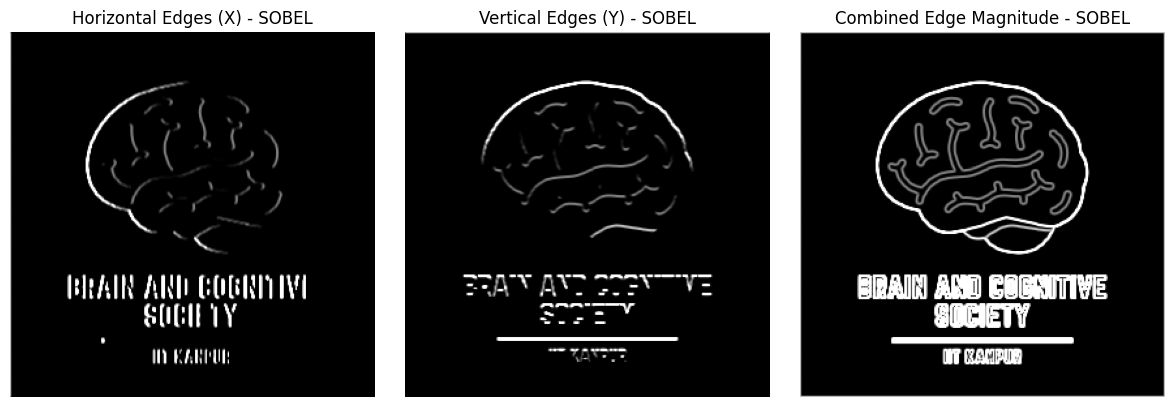

In [73]:
# plotting the results

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Horizontal Edges (X) - SOBEL")
plt.imshow(tensor_to_img(edges_x), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Vertical Edges (Y) - SOBEL")
plt.imshow(tensor_to_img(edges_y), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Combined Edge Magnitude - SOBEL")
plt.imshow(tensor_to_img(edges_magnitude), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

USING SCHARR KERNEL

In [74]:
# convolution
conv_x = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)
conv_y = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)

# assigning our desired kernels as weights
conv_x.weight = nn.Parameter(scharr_x_kernel)
conv_y.weight = nn.Parameter(scharr_y_kernel)

# applying conv
with torch.no_grad():
    edges_x = conv_x(img_tensor)
    edges_y = conv_y(img_tensor)

    # combining horizontal and vertical
    edges_magnitude = torch.sqrt(edges_x ** 2 + edges_y ** 2)



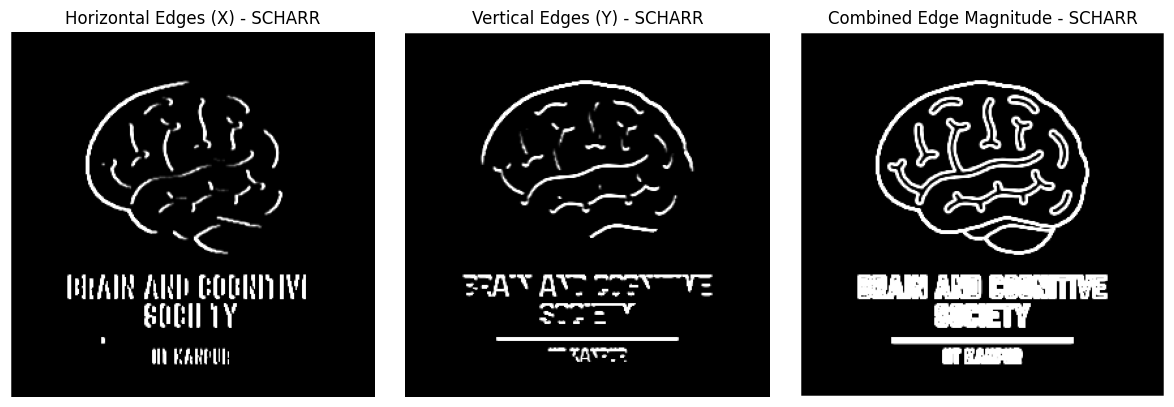

In [75]:
# plotting the results

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Horizontal Edges (X) - SCHARR")
plt.imshow(tensor_to_img(edges_x), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Vertical Edges (Y) - SCHARR")
plt.imshow(tensor_to_img(edges_y), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Combined Edge Magnitude - SCHARR")
plt.imshow(tensor_to_img(edges_magnitude), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

## second order kernel

USING LAPLACIAN

In [76]:
# convolution
conv_lap = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)

# assigning our desired kernels as weights
conv_lap.weight = nn.Parameter(laplacian_kernel)

# applying conv
with torch.no_grad():
    edges_lap = conv_lap(img_tensor)



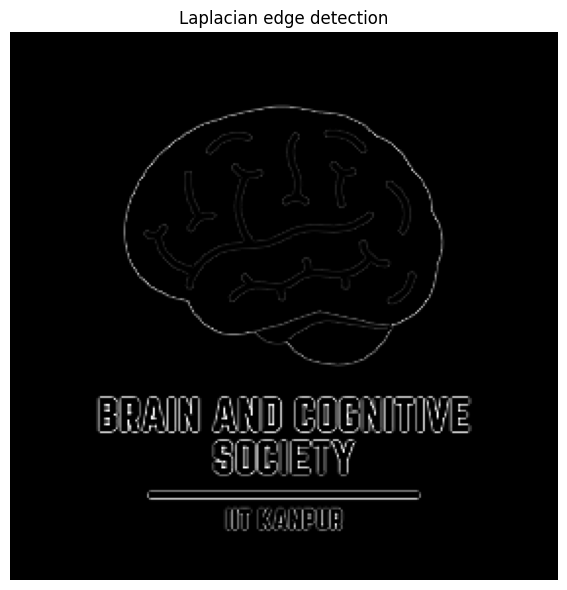

In [77]:
# plotting the results

plt.figure(figsize=(6, 6))
plt.title("Laplacian edge detection")
plt.imshow(tensor_to_img(edges_lap), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

LAPLACINAN DIAGONAL KERNEL


In [78]:
# convolution
conv_lap_diag = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)

# assigning our desired kernels as weights
conv_lap_diag.weight = nn.Parameter(laplacian_diagonal_kernel)

# applying conv
with torch.no_grad():
    edges_lap_diag = conv_lap_diag(img_tensor)



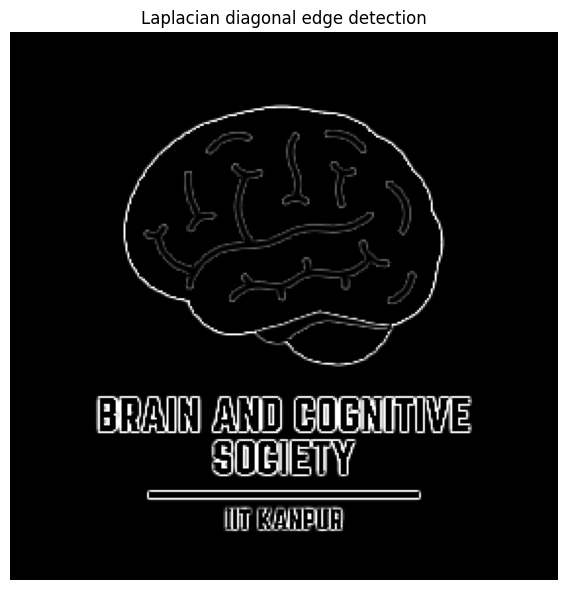

In [79]:
# plotting the results

plt.figure(figsize=(6, 6))
plt.title("Laplacian diagonal edge detection")
plt.imshow(tensor_to_img(edges_lap_diag), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

## canny algorithm

In [80]:
# convolution
conv_gauss = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
conv_x = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
conv_y = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)


# assigning our desired kernels as weights
conv_gauss.weight = nn.Parameter(gaussian_kernel)
conv_x.weight = nn.Parameter(sobel_x_kernel)
conv_y.weight = nn.Parameter(sobel_y_kernel)

with torch.no_grad():
    # smooth image to reduce noise
    blurred = conv_gauss(img_tensor)

    # calculating gradients
    gx = conv_x(blurred)
    gy = conv_y(blurred)

    # grad mag
    magnitude = torch.sqrt(gx**2 + gy**2)
    magnitude = magnitude / (magnitude.max() + 1e-8) # normalize

# double thresholding (strong and weak edges)
low_threshold = 0.15
high_threshold = 0.35

strong_edges = (magnitude >= high_threshold).float()
weak_edges = ((magnitude >= low_threshold) & (magnitude < high_threshold)).float()

# combined tensor representation
canny_tensor = strong_edges + (0.5 * weak_edges)

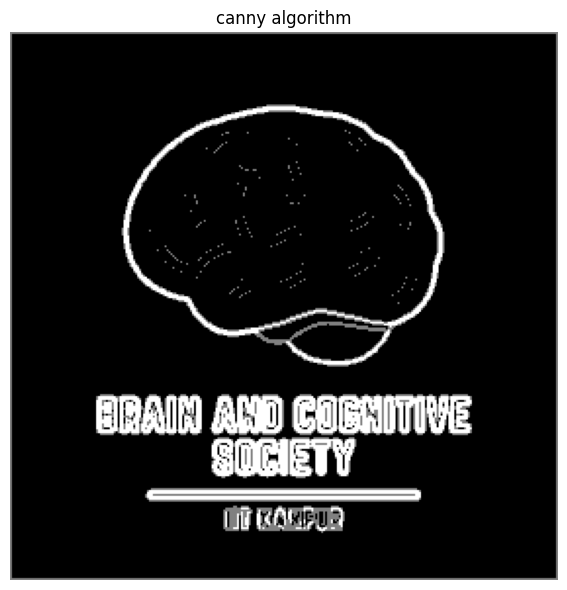

In [81]:
# plotting the results

plt.figure(figsize=(6, 6))
plt.title("canny algorithm")
plt.imshow(tensor_to_img(canny_tensor), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()